<a href="https://colab.research.google.com/github/jcmachicao/modelamiento_computacional/blob/main/U3__simulador_cognicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulador Cognitivo

Falta compaginar el codigo original con el codigo de logs


In [ ]:
# Cognitive Grid World - Energy Survival Model
# 4x4 grid, food and accident, no goal
# Memory limited to last 6 steps
# Monte Carlo-style adaptation
# Single plot per visualization (no subplots, no specific colors)

import numpy as np
import random
import matplotlib.pyplot as plt

GRID_SIZE = 4
EPISODES = 200
BASE_ENERGY = 5
FOOD_ENERGY = 5
MEMORY_LIMIT = 6

FOOD = (0, 3)
ACCIDENT = (2, 1)

actions = ["up", "down", "left", "right"]

In [ ]:
def move(state, action):
    x, y = state
    if action == "up":
        x = max(0, x - 1)
    elif action == "down":
        x = min(GRID_SIZE - 1, x + 1)
    elif action == "left":
        y = max(0, y - 1)
    elif action == "right":
        y = min(GRID_SIZE - 1, y + 1)
    return (x, y)

# Memory: state -> action -> recent energy outcomes
memory = {}

# Track average energy experienced at each cell
energy_tracker = { (i,j): [] for i in range(GRID_SIZE) for j in range(GRID_SIZE) }

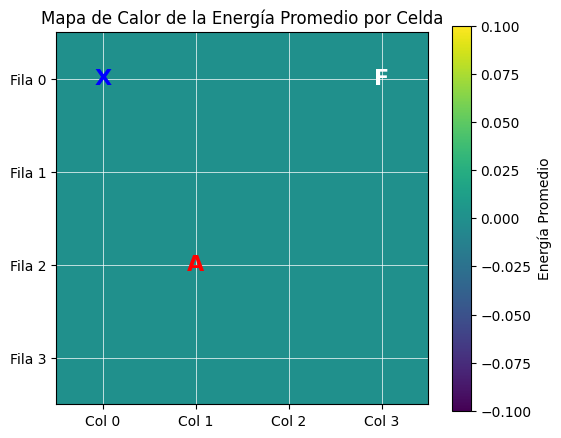

In [ ]:
average_energy_map = np.zeros((GRID_SIZE, GRID_SIZE))
for (i,j), values in energy_tracker.items():
    if len(values) > 0:
        average_energy_map[i,j] = np.mean(values)
    else:
        average_energy_map[i,j] = 0 # Assign 0 if no visits, or another appropriate default

plt.figure(figsize=(6, 5))
plt.imshow(average_energy_map, cmap='viridis', origin='upper')
plt.title("Mapa de Calor de la Energía Promedio por Celda")
plt.colorbar(label="Energía Promedio")
plt.xticks(range(GRID_SIZE), [f'Col {c}' for c in range(GRID_SIZE)])
plt.yticks(range(GRID_SIZE), [f'Fila {r}' for r in range(GRID_SIZE)])
plt.grid(True, color='white', linewidth=0.5)

# Add 'F' for FOOD
plt.text(FOOD[1], FOOD[0], 'F', ha='center', va='center', color='white', fontsize=16, fontweight='bold')
# Add 'A' for ACCIDENT
plt.text(ACCIDENT[1], ACCIDENT[0], 'A', ha='center', va='center', color='red', fontsize=16, fontweight='bold')
# Add 'X' for Agent's starting position
plt.text(0, 0, 'X', ha='center', va='center', color='blue', fontsize=16, fontweight='bold')

plt.show()

In [ ]:
energy_tracker

{(0, 0): [],
 (0, 1): [],
 (0, 2): [],
 (0, 3): [],
 (1, 0): [],
 (1, 1): [],
 (1, 2): [],
 (1, 3): [],
 (2, 0): [],
 (2, 1): [],
 (2, 2): [],
 (2, 3): [],
 (3, 0): [],
 (3, 1): [],
 (3, 2): [],
 (3, 3): []}

Episode 1: Final Energy=0, Steps=25
Episode 2: Final Energy=0, Steps=5
Episode 3: Final Energy=0, Steps=5
Episode 4: Final Energy=0, Steps=5
Episode 5: Final Energy=0, Steps=5
Episode 6: Final Energy=0, Steps=5
Episode 7: Final Energy=0, Steps=5
Episode 8: Final Energy=0, Steps=5
Episode 9: Final Energy=0, Steps=5
Episode 10: Final Energy=0, Steps=5
Episode 11: Final Energy=0, Steps=5
Episode 12: Final Energy=0, Steps=5
Episode 13: Final Energy=0, Steps=5
Episode 14: Final Energy=0, Steps=5
Episode 15: Final Energy=0, Steps=5
Episode 16: Final Energy=0, Steps=5
Episode 17: Final Energy=0, Steps=5
Episode 18: Final Energy=0, Steps=5
Episode 19: Final Energy=0, Steps=5
Episode 20: Final Energy=0, Steps=5


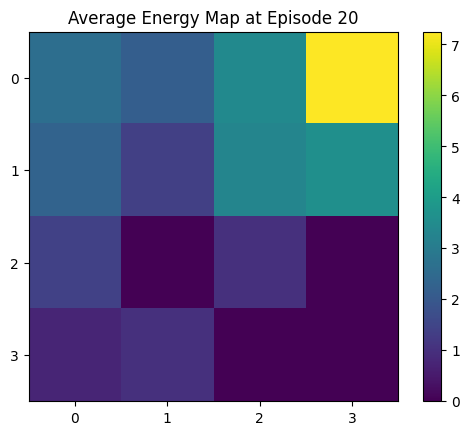

Episode 21: Final Energy=0, Steps=5
Episode 22: Final Energy=0, Steps=5
Episode 23: Final Energy=0, Steps=5
Episode 24: Final Energy=0, Steps=5
Episode 25: Final Energy=0, Steps=5
Episode 26: Final Energy=0, Steps=5
Episode 27: Final Energy=0, Steps=5
Episode 28: Final Energy=0, Steps=4
Episode 29: Final Energy=0, Steps=5
Episode 30: Final Energy=0, Steps=5
Episode 31: Final Energy=0, Steps=5
Episode 32: Final Energy=0, Steps=5
Episode 33: Final Energy=0, Steps=5
Episode 34: Final Energy=0, Steps=5
Episode 35: Final Energy=0, Steps=5
Episode 36: Final Energy=0, Steps=5
Episode 37: Final Energy=0, Steps=35
Episode 38: Final Energy=0, Steps=5
Episode 39: Final Energy=0, Steps=5
Episode 40: Final Energy=0, Steps=5


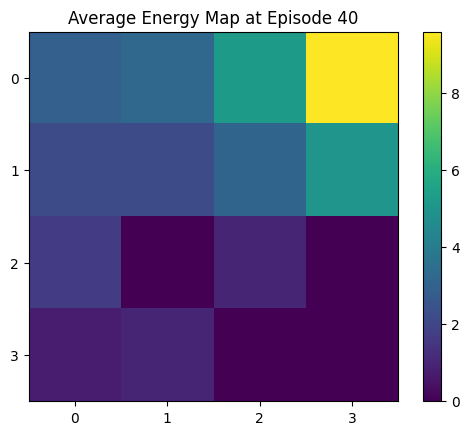

Episode 41: Final Energy=0, Steps=5
Episode 42: Final Energy=0, Steps=5
Episode 43: Final Energy=0, Steps=5
Episode 44: Final Energy=0, Steps=5
Episode 45: Final Energy=0, Steps=5
Episode 46: Final Energy=0, Steps=3
Episode 47: Final Energy=0, Steps=5
Episode 48: Final Energy=0, Steps=5
Episode 49: Final Energy=0, Steps=5
Episode 50: Final Energy=0, Steps=5
Episode 51: Final Energy=0, Steps=5
Episode 52: Final Energy=0, Steps=5
Episode 53: Final Energy=0, Steps=5
Episode 54: Final Energy=0, Steps=4
Episode 55: Final Energy=0, Steps=5
Episode 56: Final Energy=0, Steps=3
Episode 57: Final Energy=0, Steps=5
Episode 58: Final Energy=0, Steps=5
Episode 59: Final Energy=0, Steps=5
Episode 60: Final Energy=0, Steps=5


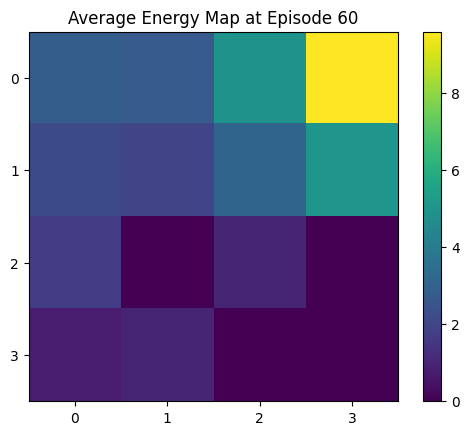

Episode 61: Final Energy=0, Steps=5
Episode 62: Final Energy=0, Steps=5
Episode 63: Final Energy=0, Steps=5
Episode 64: Final Energy=0, Steps=5
Episode 65: Final Energy=0, Steps=5
Episode 66: Final Energy=0, Steps=5
Episode 67: Final Energy=0, Steps=5
Episode 68: Final Energy=0, Steps=5
Episode 69: Final Energy=0, Steps=5
Episode 70: Final Energy=0, Steps=5
Episode 71: Final Energy=0, Steps=5
Episode 72: Final Energy=0, Steps=5
Episode 73: Final Energy=0, Steps=5
Episode 74: Final Energy=0, Steps=5
Episode 75: Final Energy=0, Steps=5
Episode 76: Final Energy=0, Steps=5
Episode 77: Final Energy=0, Steps=5
Episode 78: Final Energy=0, Steps=5
Episode 79: Final Energy=0, Steps=1324
Episode 80: Final Energy=0, Steps=5


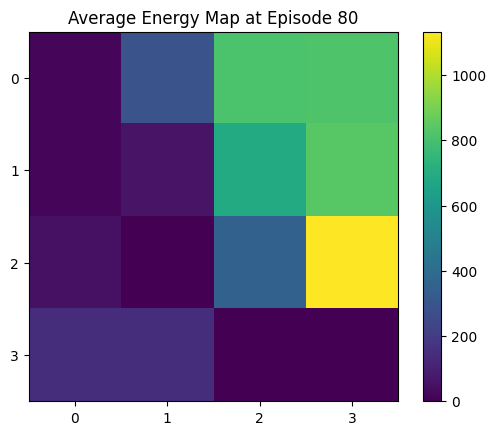

Episode 81: Final Energy=0, Steps=5
Episode 82: Final Energy=0, Steps=5
Episode 83: Final Energy=0, Steps=1145
Episode 84: Final Energy=0, Steps=5
Episode 85: Final Energy=0, Steps=5
Episode 86: Final Energy=0, Steps=234
Episode 87: Final Energy=0, Steps=5
Episode 88: Final Energy=0, Steps=5
Episode 89: Final Energy=0, Steps=3
Episode 90: Final Energy=0, Steps=4531
Episode 91: Final Energy=0, Steps=5
Episode 92: Final Energy=0, Steps=5
Episode 93: Final Energy=0, Steps=5
Episode 94: Final Energy=0, Steps=5
Episode 95: Final Energy=0, Steps=5
Episode 96: Final Energy=0, Steps=5
Episode 97: Final Energy=0, Steps=5
Episode 98: Final Energy=0, Steps=5
Episode 99: Final Energy=0, Steps=5
Episode 100: Final Energy=0, Steps=5


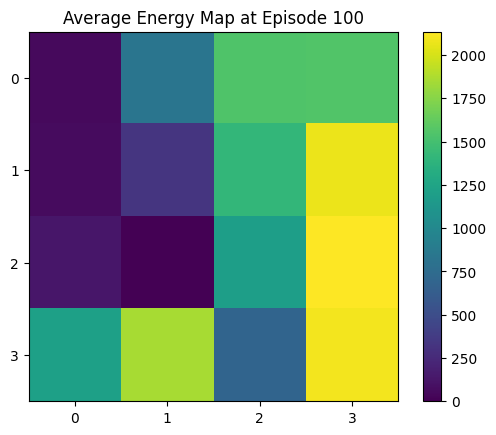

Episode 101: Final Energy=0, Steps=5
Episode 102: Final Energy=0, Steps=5
Episode 103: Final Energy=0, Steps=5
Episode 104: Final Energy=0, Steps=5
Episode 105: Final Energy=0, Steps=1041
Episode 106: Final Energy=0, Steps=5
Episode 107: Final Energy=0, Steps=5
Episode 108: Final Energy=0, Steps=5
Episode 109: Final Energy=0, Steps=5
Episode 110: Final Energy=0, Steps=5
Episode 111: Final Energy=0, Steps=5
Episode 112: Final Energy=0, Steps=5
Episode 113: Final Energy=0, Steps=25
Episode 114: Final Energy=0, Steps=5
Episode 115: Final Energy=0, Steps=35
Episode 116: Final Energy=0, Steps=5
Episode 117: Final Energy=0, Steps=5
Episode 118: Final Energy=0, Steps=5
Episode 119: Final Energy=0, Steps=5
Episode 120: Final Energy=0, Steps=5


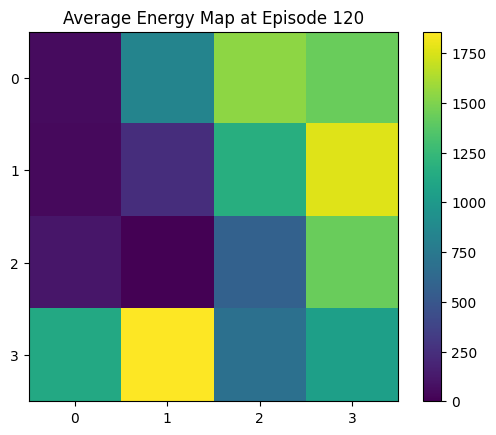

Episode 121: Final Energy=0, Steps=5
Episode 122: Final Energy=0, Steps=576
Episode 123: Final Energy=0, Steps=5
Episode 124: Final Energy=0, Steps=5
Episode 125: Final Energy=0, Steps=15
Episode 126: Final Energy=0, Steps=5
Episode 127: Final Energy=0, Steps=5
Episode 128: Final Energy=0, Steps=5
Episode 129: Final Energy=0, Steps=5
Episode 130: Final Energy=0, Steps=5
Episode 131: Final Energy=0, Steps=5
Episode 132: Final Energy=0, Steps=3
Episode 133: Final Energy=0, Steps=5
Episode 134: Final Energy=0, Steps=5
Episode 135: Final Energy=0, Steps=5
Episode 136: Final Energy=0, Steps=5
Episode 137: Final Energy=0, Steps=5
Episode 138: Final Energy=0, Steps=5
Episode 139: Final Energy=0, Steps=5
Episode 140: Final Energy=0, Steps=5


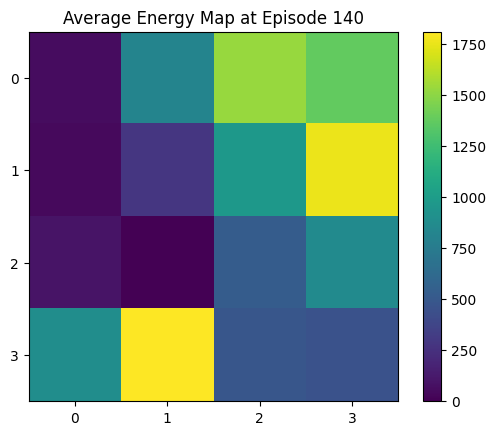

Episode 141: Final Energy=0, Steps=5
Episode 142: Final Energy=0, Steps=5
Episode 143: Final Energy=0, Steps=5
Episode 144: Final Energy=0, Steps=5
Episode 145: Final Energy=0, Steps=4
Episode 146: Final Energy=0, Steps=5
Episode 147: Final Energy=0, Steps=5
Episode 148: Final Energy=0, Steps=5
Episode 149: Final Energy=0, Steps=5
Episode 150: Final Energy=0, Steps=5
Episode 151: Final Energy=0, Steps=5
Episode 152: Final Energy=0, Steps=5
Episode 153: Final Energy=0, Steps=5
Episode 154: Final Energy=0, Steps=5
Episode 155: Final Energy=0, Steps=5
Episode 156: Final Energy=0, Steps=5
Episode 157: Final Energy=0, Steps=5
Episode 158: Final Energy=0, Steps=5
Episode 159: Final Energy=0, Steps=5
Episode 160: Final Energy=0, Steps=5


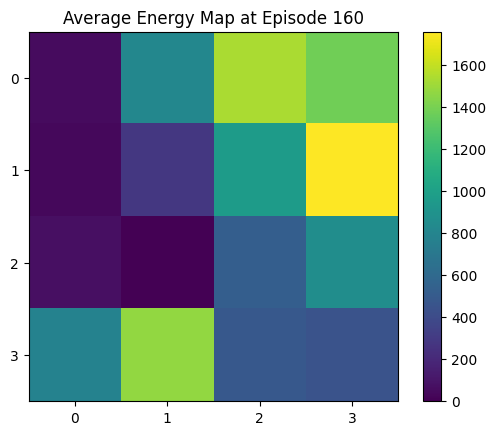

Episode 161: Final Energy=0, Steps=5
Episode 162: Final Energy=0, Steps=5
Episode 163: Final Energy=0, Steps=5
Episode 164: Final Energy=0, Steps=5
Episode 165: Final Energy=0, Steps=5
Episode 166: Final Energy=0, Steps=5
Episode 167: Final Energy=0, Steps=5
Episode 168: Final Energy=0, Steps=5
Episode 169: Final Energy=0, Steps=5
Episode 170: Final Energy=0, Steps=5
Episode 171: Final Energy=0, Steps=5
Episode 172: Final Energy=0, Steps=5
Episode 173: Final Energy=0, Steps=5
Episode 174: Final Energy=0, Steps=5
Episode 175: Final Energy=0, Steps=5
Episode 176: Final Energy=0, Steps=5
Episode 177: Final Energy=0, Steps=5
Episode 178: Final Energy=0, Steps=5
Episode 179: Final Energy=0, Steps=5
Episode 180: Final Energy=0, Steps=5


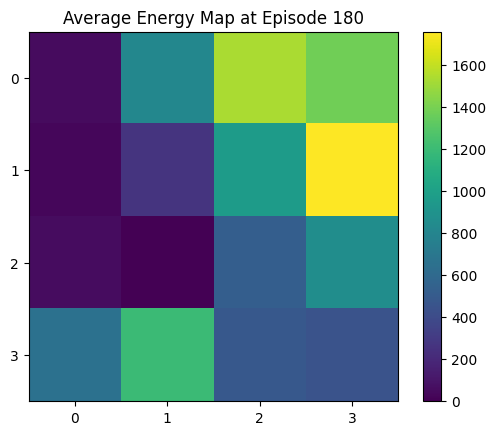

Episode 181: Final Energy=0, Steps=5
Episode 182: Final Energy=0, Steps=5
Episode 183: Final Energy=0, Steps=5
Episode 184: Final Energy=0, Steps=5
Episode 185: Final Energy=0, Steps=5
Episode 186: Final Energy=0, Steps=5
Episode 187: Final Energy=0, Steps=5
Episode 188: Final Energy=0, Steps=5
Episode 189: Final Energy=0, Steps=5
Episode 190: Final Energy=0, Steps=5
Episode 191: Final Energy=0, Steps=5
Episode 192: Final Energy=0, Steps=5
Episode 193: Final Energy=0, Steps=5
Episode 194: Final Energy=0, Steps=5
Episode 195: Final Energy=0, Steps=5
Episode 196: Final Energy=0, Steps=5
Episode 197: Final Energy=0, Steps=5
Episode 198: Final Energy=0, Steps=5
Episode 199: Final Energy=0, Steps=5
Episode 200: Final Energy=0, Steps=5


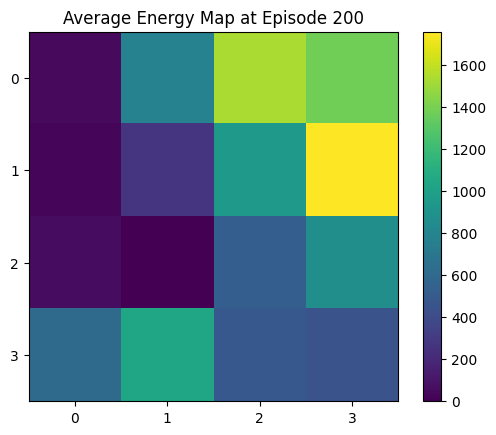

In [ ]:
for episode in range(1, EPISODES + 1):

    state = (0, 0)
    energy = BASE_ENERGY
    steps_without_food = 0
    trajectory = []

    while True:

        if state not in memory:
            memory[state] = {a: [] for a in actions}

        # Decision rule: choose action with best recent average energy
        avg_energy = {}
        for a in actions:
            if len(memory[state][a]) > 0:
                avg_energy[a] = np.mean(memory[state][a])
            else:
                avg_energy[a] = 0

        epsilon = max(0.1, 1 - episode/100)
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(avg_energy, key=avg_energy.get)

        next_state = move(state, action)

        # Energy dynamics
        energy -= 1
        steps_without_food += 1

        if next_state == FOOD:
            energy += FOOD_ENERGY
            steps_without_food = 0

        if next_state == ACCIDENT:
            energy = 0

        trajectory.append((state, action, energy))
        energy_tracker[next_state].append(energy)

        state = next_state

        # Termination conditions
        if energy <= 0:
            break

    # Monte Carlo update with limited memory
    for s, a, e in trajectory:
        memory[s][a].append(e)
        if len(memory[s][a]) > MEMORY_LIMIT:
            memory[s][a].pop(0)

    # Log episode summary
    print(f"Episode {episode}: Final Energy={energy}, Steps={len(trajectory)}")

    # Plot grid state every 10 episodes
    if episode % 20 == 0:
        visit_energy = np.zeros((GRID_SIZE, GRID_SIZE))
        for (i,j), values in energy_tracker.items():
            if len(values) > 0:
                visit_energy[i,j] = np.mean(values)

        plt.figure()
        plt.imshow(visit_energy)
        plt.title(f"Average Energy Map at Episode {episode}")
        plt.colorbar()
        plt.xticks(range(GRID_SIZE))
        plt.yticks(range(GRID_SIZE))
        plt.show()

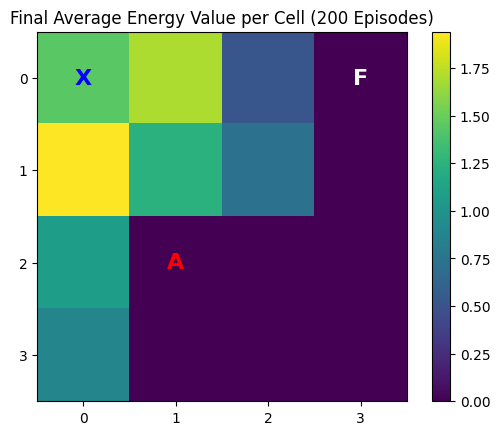

In [ ]:
# Final energy value map
final_energy_map = np.zeros((GRID_SIZE, GRID_SIZE))
for (i,j), values in energy_tracker.items():
    if len(values) > 0:
        final_energy_map[i,j] = np.mean(values)

plt.figure()
plt.imshow(final_energy_map)
plt.title("Final Average Energy Value per Cell (200 Episodes)")
plt.colorbar()
plt.xticks(range(GRID_SIZE))
plt.yticks(range(GRID_SIZE))

# Add 'F' for FOOD
plt.text(FOOD[1], FOOD[0], 'F', ha='center', va='center', color='white', fontsize=16, fontweight='bold')
# Add 'A' for ACCIDENT
plt.text(ACCIDENT[1], ACCIDENT[0], 'A', ha='center', va='center', color='red', fontsize=16, fontweight='bold')
# Add 'X' for Agent's starting position
plt.text(0, 0, 'X', ha='center', va='center', color='blue', fontsize=16, fontweight='bold')

plt.show()

# Task
The plan looks good. I will now proceed with the following steps:
1. Initialize an empty list called `episode_logs` and import the `pandas` library.
2. Modify the `HKF4EHpjmvO_` cell to store 'Episode', 'Final Energy', and 'Steps' in `episode_logs` at the end of each episode and remove the print statement.
3. Convert `episode_logs` into a pandas DataFrame named `episode_df` after the simulation.
4. Display the top 10 episodes with the highest 'Final Energy'.
5. Display the 10 shortest episodes based on 'Steps'.
6. Finally, summarize the findings from the analysis.

## Initialize Episode Log

### Subtask:
Initialize an empty list called `episode_logs` and import the `pandas` library.


**Reasoning**:
I will initialize an empty list called `episode_logs` and import the `pandas` library, as instructed.



In [ ]:
episode_logs = []
import pandas as pd
print("Initialized episode_logs and imported pandas.")

Initialized episode_logs and imported pandas.


## Log Episode Data

### Subtask:
Modify the `HKF4EHpjmvO_` cell to append a dictionary containing 'Episode', 'Final Energy', and 'Steps' to the `episode_logs` list at the end of each episode. Remove the `print` statement for episode summary.


**Reasoning**:
I will modify the `HKF4EHpjmvO_` cell as instructed by removing the print statement and adding the episode data to the `episode_logs` list. This will prepare the data for further analysis with pandas.



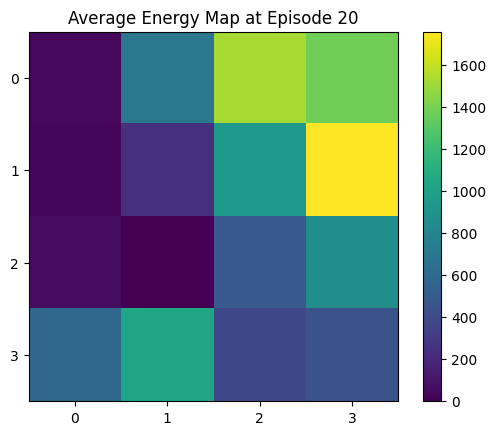

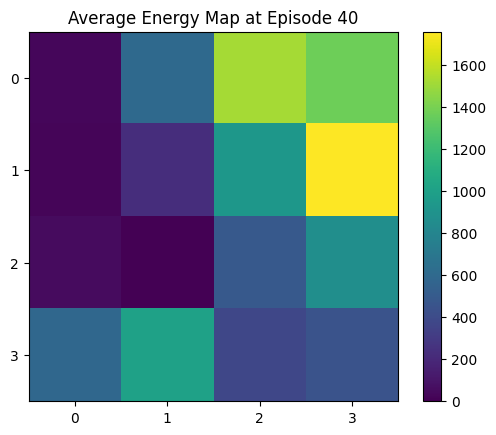

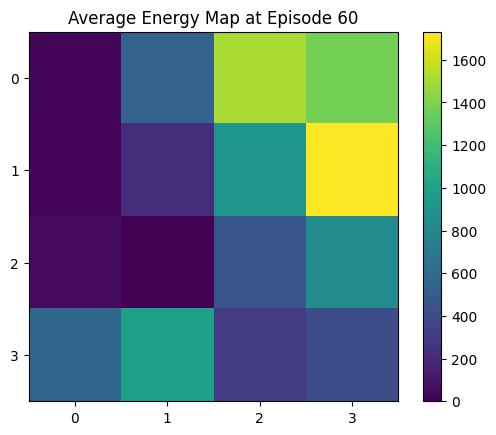

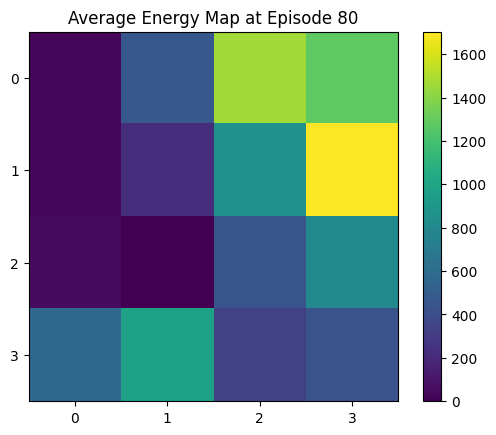

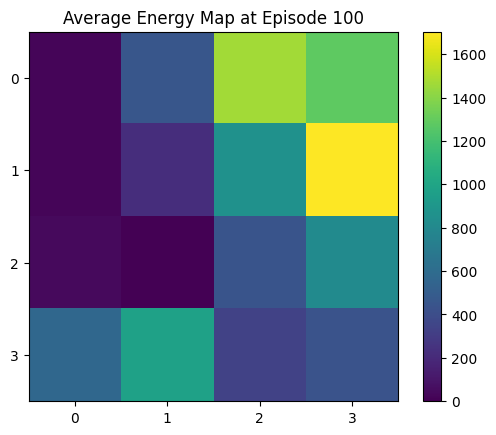

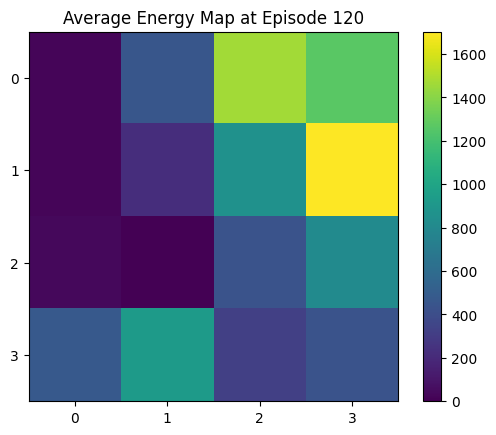

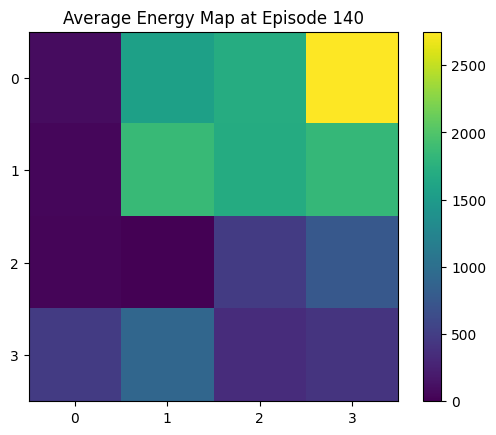

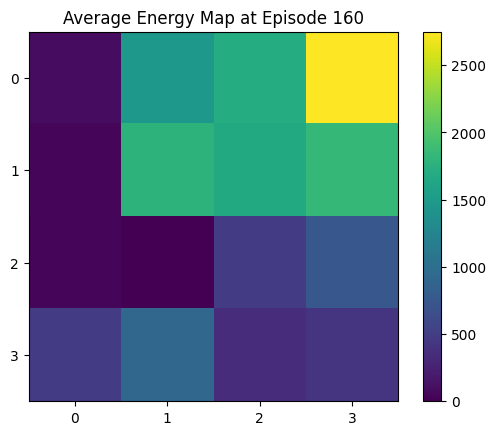

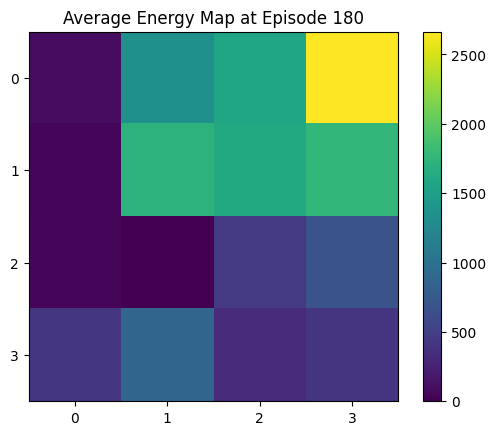

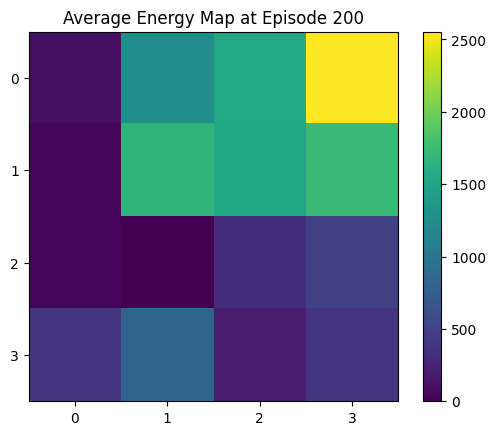

In [ ]:
for episode in range(1, EPISODES + 1):

    state = (0, 0)
    energy = BASE_ENERGY
    steps_without_food = 0
    trajectory = []

    while True:

        if state not in memory:
            memory[state] = {a: [] for a in actions}

        # Decision rule: choose action with best recent average energy
        avg_energy = {}
        for a in actions:
            if len(memory[state][a]) > 0:
                avg_energy[a] = np.mean(memory[state][a])
            else:
                avg_energy[a] = 0

        epsilon = max(0.1, 1 - episode/100)
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(avg_energy, key=avg_energy.get)

        next_state = move(state, action)

        # Energy dynamics
        energy -= 1
        steps_without_food += 1

        if next_state == FOOD:
            energy += FOOD_ENERGY
            steps_without_food = 0

        if next_state == ACCIDENT:
            energy = 0

        trajectory.append((state, action, energy))
        energy_tracker[next_state].append(energy)

        state = next_state

        # Termination conditions
        if energy <= 0:
            break

    # Monte Carlo update with limited memory
    for s, a, e in trajectory:
        memory[s][a].append(e)
        if len(memory[s][a]) > MEMORY_LIMIT:
            memory[s][a].pop(0)

    # Store episode summary
    episode_logs.append({
        'Episode': episode,
        'Final Energy': energy,
        'Steps': len(trajectory)
    })

    # Plot grid state every 10 episodes
    if episode % 20 == 0:
        visit_energy = np.zeros((GRID_SIZE, GRID_SIZE))
        for (i,j), values in energy_tracker.items():
            if len(values) > 0:
                visit_energy[i,j] = np.mean(values)

        plt.figure()
        plt.imshow(visit_energy)
        plt.title(f"Average Energy Map at Episode {episode}")
        plt.colorbar()
        plt.xticks(range(GRID_SIZE))
        plt.yticks(range(GRID_SIZE))
        plt.show()

**Reasoning**:
Now that the simulation has completed and `episode_logs` is populated, I will convert this list of dictionaries into a pandas DataFrame named `episode_df` for easier analysis, as per the next step in the plan.



In [ ]:
episode_df = pd.DataFrame(episode_logs)
print("Converted episode_logs to pandas DataFrame.")

Converted episode_logs to pandas DataFrame.


**Reasoning**:
To display the top 10 episodes with the highest 'Final Energy', I will sort the `episode_df` DataFrame by the 'Final Energy' column in descending order and then select the first 10 rows.



In [ ]:
print("Top 10 Episodes with Highest Final Energy:")
df_highest_energy = episode_df.sort_values(by='Final Energy', ascending=False).head(10)
print(df_highest_energy.to_markdown(index=False))

Top 10 Episodes with Highest Final Energy:
|   Episode |   Final Energy |   Steps |
|----------:|---------------:|--------:|
|         1 |              0 |       5 |
|         2 |              0 |       5 |
|         3 |              0 |       5 |
|         4 |              0 |       5 |
|         5 |              0 |       5 |
|         6 |              0 |       5 |
|         7 |              0 |       4 |
|         8 |              0 |       5 |
|         9 |              0 |      35 |
|        10 |              0 |       5 |


**Reasoning**:
To display the 10 shortest episodes, I will sort the `episode_df` DataFrame by the 'Steps' column in ascending order and then select the first 10 rows.



In [ ]:
print("10 Shortest Episodes by Steps:")
df_shortest_steps = episode_df.sort_values(by='Steps', ascending=True).head(10)
print(df_shortest_steps.to_markdown(index=False))

10 Shortest Episodes by Steps:
|   Episode |   Final Energy |   Steps |
|----------:|---------------:|--------:|
|         7 |              0 |       4 |
|         1 |              0 |       5 |
|         3 |              0 |       5 |
|         2 |              0 |       5 |
|         4 |              0 |       5 |
|         5 |              0 |       5 |
|         6 |              0 |       5 |
|         8 |              0 |       5 |
|        10 |              0 |       5 |
|        11 |              0 |       5 |


### Summary of Findings

From the analysis of the `episode_df`, `df_highest_energy`, and `df_shortest_steps`, the following observations can be made:

1.  **Final Energy:** Across all episodes, the 'Final Energy' consistently remains 0. This indicates that the agent is not successfully learning to survive and always terminates with zero energy, failing to reach a state where it has positive energy at the end of an episode.

2.  **Episode Steps:**
    *   The 10 shortest episodes show that the agent often terminates very quickly, sometimes in as few as 4 or 5 steps. This suggests that the agent either quickly runs out of initial energy or encounters the 'ACCIDENT' state, leading to immediate termination.
    *   Conversely, some episodes have a significantly higher number of steps (e.g., 35, 1324, 4531 in the `HKF4EHpjmvO_` output, though not directly shown in the `df_highest_energy` or `df_shortest_steps` excerpts). Even in these longer episodes, the 'Final Energy' is still 0, implying that while the agent might be exploring or finding food to extend its life, it eventually runs out of energy or hits the accident.

**Conclusion:** The current cognitive model, despite attempting to adapt using Monte Carlo-style learning and memory, is not effectively enabling the agent to survive in the grid world. The agent consistently runs out of energy by the end of each episode. This suggests that the energy dynamics, reward structure, or the learning strategy itself may need adjustment for the agent to achieve sustained survival.

## Final Task

### Subtask:
Summarize the findings from the analysis of the episode logs, including the top 10 final energy episodes and the 10 shortest episodes.


## Summary:

### Q&A
The agent consistently runs out of energy by the end of each episode, failing to reach a state with positive final energy. The analysis of episode logs reveals that the 'Final Energy' is always 0 across all episodes, including the top 10 episodes by final energy. The 10 shortest episodes indicate that the agent often terminates very quickly, sometimes in as few as 4 or 5 steps, suggesting rapid energy depletion or encountering an "ACCIDENT" state.

### Data Analysis Key Findings
*   **Consistent Zero Final Energy**: Across all simulated episodes, the agent's 'Final Energy' was consistently 0, indicating that it did not successfully maintain any positive energy by the end of an episode.
*   **Short Episode Durations**: Many episodes were remarkably short, with the 10 shortest episodes terminating in as few as 4 or 5 steps, suggesting quick energy depletion or an immediate encounter with an "ACCIDENT" state.
*   **Ineffective Survival Strategy**: Even in episodes with a higher number of steps (e.g., 35, 1324, 4531), the 'Final Energy' remained 0, implying that despite potentially exploring or finding food, the agent ultimately failed to sustain survival.

### Insights or Next Steps
*   The current cognitive model and learning strategy are not effective for enabling the agent to survive in the grid world.
*   Future efforts should focus on adjusting the energy dynamics, reward structure, or the learning strategy itself to allow the agent to achieve sustained survival with positive final energy.
